<a href="https://colab.research.google.com/github/lightcode01-oss/IYB_INTERNSHIP/blob/main/YBI_45_Days_Student_Performance_Prediction(DAY02).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DAY 02 — Dataset Research and Selection

## Dataset Selection

For this project, the UCI Student Performance dataset has been selected.

The dataset contains information about students from two Portuguese secondary
schools and includes academic, demographic, social and school-related
attributes.

The dataset can be used for both classification and regression tasks.

### Selected Dataset

**Dataset Name:** Student Performance

**Source:** UCI Machine Learning Repository

**Dataset ID:** 320

**Primary Target:** G3 (Final Grade)

### Reason for Selection

The dataset was selected because it contains a diverse set of variables that
can be used to study factors associated with student academic performance.

The dataset also provides an opportunity to experiment with both regression
and classification approaches.

### Important Data Consideration

The variables G1 and G2 represent earlier-period grades, while G3 represents
the final grade.

Because G1 and G2 have a strong relationship with G3, the project will
investigate models both with and without these variables. This will help
compare direct academic-history prediction with prediction based more heavily
on non-grade student characteristics.

In [ ]:
# DAY 02
# Installing the package used to access datasets from the
# UCI Machine Learning Repository

!pip -q install ucimlrepo

print("ucimlrepo installed successfully.")

ucimlrepo installed successfully.


In [ ]:
from ucimlrepo import fetch_ucirepo

# Fetch UCI Student Performance dataset
student_performance = fetch_ucirepo(id=320)

print("Dataset downloaded successfully.")

Dataset downloaded successfully.


In [ ]:
# Extract features and target

X = student_performance.data.features
y = student_performance.data.targets

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (649, 30)
Target shape: (649, 3)


In [ ]:
# Display the first five rows of the feature dataset

X.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,yes,no,no,4,3,4,1,1,3,4
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,yes,yes,no,5,3,3,1,1,3,2
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,yes,yes,no,4,3,2,2,3,3,6
3,GP,F,15,U,GT3,T,4,2,health,services,...,yes,yes,yes,3,2,2,1,1,5,0
4,GP,F,16,U,GT3,T,3,3,other,other,...,yes,no,no,4,3,2,1,2,5,0


In [ ]:
# Display the target variable

y.head()

,G1,G2,G3
0,0,11,11
1,9,11,11
2,12,13,12
3,14,14,14
4,11,13,13


In [ ]:
# Display basic information available from UCI

print("Dataset Name:")
print(student_performance.metadata.get("name"))

print("\nDataset Description:")
print(student_performance.metadata.get("abstract"))

print("\nNumber of Features:")
print(len(student_performance.variables))

Dataset Name:
Student Performance

Dataset Description:
Predict student performance in secondary education (high school). 

Number of Features:
33


In [ ]:
# Display the dataset variable information

student_performance.variables

,name,role,type,demographic,description,units,missing_values
0,school,Feature,Categorical,None,student's school (binary: 'GP' - Gabriel Perei...,None,no
1,sex,Feature,Binary,Sex,student's sex (binary: 'F' - female or 'M' - m...,None,no
2,age,Feature,Integer,Age,student's age (numeric: from 15 to 22),None,no
3,address,Feature,Categorical,None,student's home address type (binary: 'U' - urb...,None,no
4,famsize,Feature,Categorical,Other,family size (binary: 'LE3' - less or equal to ...,None,no
5,Pstatus,Feature,Categorical,Other,parent's cohabitation status (binary: 'T' - li...,None,no
6,Medu,Feature,Integer,Education Level,"mother's education (numeric: 0 - none, 1 - pr...",None,no
7,Fedu,Feature,Integer,Education Level,"father's education (numeric: 0 - none, 1 - pr...",None,no
8,Mjob,Feature,Categorical,Occupation,"mother's job (nominal: 'teacher', 'health' car...",None,no
9,Fjob,Feature,Categorical,Occupation,"father's job (nominal: 'teacher', 'health' car...",None,no


In [ ]:
# Basic information about the feature dataset

print("Number of rows:", X.shape[0])
print("Number of columns:", X.shape[1])

print("\nColumn names:")
print(X.columns.tolist())

Number of rows: 649
Number of columns: 30

Column names:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']


In [ ]:
# Check for missing values

missing_values = X.isnull().sum()

print("Missing values in each feature:")
print(missing_values)

print("\nTotal missing values:", missing_values.sum())

Missing values in each feature:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
dtype: int64

Total missing values: 0


In [ ]:
# Check for duplicate rows

duplicate_count = X.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [ ]:
# Inspect the target variable

print("Target column(s):")
print(y.columns.tolist())

print("\nTarget data type:")
print(y.dtypes)

print("\nTarget statistics:")
print(y.describe())

Target column(s):
['G1', 'G2', 'G3']

Target data type:
G1    int64
G2    int64
G3    int64
dtype: object

Target statistics:
               G1          G2          G3
count  649.000000  649.000000  649.000000
mean    11.399076   11.570108   11.906009
std      2.745265    2.913639    3.230656
min      0.000000    0.000000    0.000000
25%     10.000000   10.000000   10.000000
50%     11.000000   11.000000   12.000000
75%     13.000000   13.000000   14.000000
max     19.000000   19.000000   19.000000


In [ ]:
# Analyze the distribution of the final grade G3

g3 = y["G3"]

print("Minimum final grade:", g3.min())
print("Maximum final grade:", g3.max())
print("Average final grade:", round(g3.mean(), 2))
print("Median final grade:", g3.median())

Minimum final grade: 0
Maximum final grade: 19
Average final grade: 11.91
Median final grade: 12.0


In [ ]:
def performance_category(grade):
    if grade < 10:
        return "Low"
    elif grade < 15:
        return "Medium"
    else:
        return "High"


performance_labels = g3.apply(performance_category)

print(performance_labels.value_counts())

G3
Medium    418
High      131
Low       100
Name: count, dtype: int64


In [ ]:
# Import visualization libraries

import matplotlib.pyplot as plt
import seaborn as sns

print("Matplotlib and Seaborn loaded successfully.")

Matplotlib and Seaborn loaded successfully.


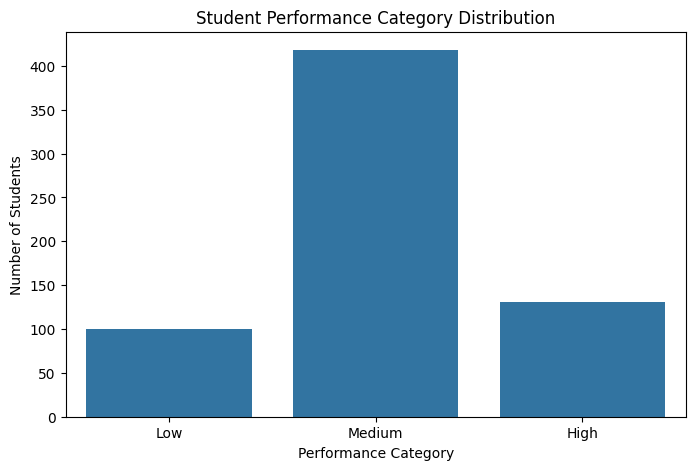

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(
    x=performance_labels,
    order=["Low", "Medium", "High"]
)

plt.title("Student Performance Category Distribution")
plt.xlabel("Performance Category")
plt.ylabel("Number of Students")

plt.show()

In [ ]:
# Combine features with the original final grade

df = X.copy()

df["G3"] = y["G3"]

df["performance_category"] = performance_labels

print("Working dataset created.")
print("Shape:", df.shape)

df.head()

Working dataset created.
Shape: (649, 32)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G3,performance_category
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,no,4,3,4,1,1,3,4,11,Medium
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,no,5,3,3,1,1,3,2,11,Medium
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,no,4,3,2,2,3,3,6,12,Medium
3,GP,F,15,U,GT3,T,4,2,health,services,...,yes,3,2,2,1,1,5,0,14,Medium
4,GP,F,16,U,GT3,T,3,3,other,other,...,no,4,3,2,1,2,5,0,13,Medium


## Day 02 — Initial Dataset Findings

### Observations

The selected dataset contains student-related academic, demographic,
social and school-related information.

The final grade (G3) is available as the primary academic outcome.

A new project-specific target called `performance_category` was created
from G3 using three categories:

- Low: G3 < 10
- Medium: 10 <= G3 < 15
- High: G3 >= 15

The dataset will be examined further before model development.

### Important Modeling Consideration

The UCI documentation indicates that G1 and G2 have a strong relationship
with G3 because they represent earlier-period grades.

Therefore, the project will later compare:

1. Models using G1 and G2.
2. Models excluding G1 and G2.

This comparison will help us understand how much prediction performance
depends on previous academic grades versus other student characteristics.

## Day 02 Development Log

### Work Completed

- Researched available datasets.
- Selected the UCI Student Performance dataset.
- Identified the dataset source and structure.
- Installed and used the `ucimlrepo` package.
- Downloaded the dataset.
- Separated features and target data.
- Inspected dataset variables.
- Checked dataset dimensions.
- Checked missing values.
- Checked duplicate records.
- Examined the final grade distribution.
- Created a project-specific performance classification.
- Created the initial working DataFrame.
- Generated the first visualization.

### Dataset Source

UCI Machine Learning Repository

Dataset:
Student Performance

Dataset ID:
320

### Next Step

Day 03 will focus on deeper data understanding and exploratory analysis of
the selected dataset.